# Comparing Jacobian sparsity matrices for `MacrophageModel`

This notebook compares several `jac_sparsity` choices for the BDF solver in `model_solver.py`:

1. `None`: no sparsity matrix, used as the reference.
2. `current`: the `_build_sparsity_matrix()` implementation currently in `model_solver.py`.
3. `block_tridiagonal`: dense variable coupling within neighbouring spatial blocks only.
4. `conservative_lower`: includes all upstream spatial dependence from the recursive velocity formula, plus one right neighbour for diffusion.
5. `compromise`: local nearest-neighbour coupling for all equations, plus upstream dependence only for the LDL, water, and HDL equations that directly use the recursive velocity.

The notebook records runtime, solver counters, sparsity density, and maximum differences relative to the no-sparsity reference.

In [11]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix, diags, kron, lil_matrix

# Assumes this notebook is in the same folder as model_solver.py.
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from model_solver import Params, MacrophageModel

## Sparsity matrix variants

The variable order in each spatial block is assumed to be

```text
m_0, m_1, ..., m_N, LDL, water, HDL
```

so each spatial block has size `N + 4`.

In [12]:
def block_tridiagonal_sparsity(p: Params) -> csr_matrix:
    """
    Dense coupling between variables within neighbouring spatial blocks only.
    This is the compact version you suggested.
    """
    block = p.N + 4
    spatial_diags = [np.ones(p.J), np.ones(p.J + 1), np.ones(p.J)]
    spatial_sparse = diags(spatial_diags, offsets=[-1, 0, 1], format="csr")
    variable_dense = csr_matrix(np.ones((block, block), dtype=int))
    return kron(spatial_sparse, variable_dense, format="csr")


def conservative_lower_sparsity(p: Params) -> csr_matrix:
    """
    Conservative pattern.
    Each spatial block may depend on all upstream blocks because u_i is recursive.
    A one-block right dependency is also included for diffusion terms involving i+1.
    """
    block = p.N + 4
    num_blocks = p.J + 1

    spatial = np.tril(np.ones((num_blocks, num_blocks), dtype=int))
    for i in range(num_blocks - 1):
        spatial[i, i + 1] = 1

    return kron(
        csr_matrix(spatial),
        csr_matrix(np.ones((block, block), dtype=int)),
        format="csr",
    )


def compromise_sparsity(p: Params) -> csr_matrix:
    """
    Middle-ground pattern.
    - All equations get local nearest-neighbour spatial coupling.
    - LDL, water, and HDL rows also get upstream dependence from the recursive u_i.
    """
    block = p.N + 4
    num_blocks = p.J + 1
    total_size = num_blocks * block
    S = lil_matrix((total_size, total_size), dtype=int)

    # Local and nearest-neighbour block coupling for every equation.
    for i in range(num_blocks):
        row_slice = slice(i * block, (i + 1) * block)
        for j in (i - 1, i, i + 1):
            if 0 <= j < num_blocks:
                col_slice = slice(j * block, (j + 1) * block)
                S[row_slice, col_slice] = 1

    # Extra upstream dependence for continuous variables because their RHS uses u_i.
    l_idx = p.N + 1
    w_idx = p.N + 2
    H_idx = p.N + 3

    for i in range(num_blocks):
        for eq in (l_idx, w_idx, H_idx):
            row = i * block + eq
            for j in range(i + 1):
                col_slice = slice(j * block, (j + 1) * block)
                S[row, col_slice] = 1

    return S.tocsr()


def current_sparsity(p: Params) -> csr_matrix:
    """Use the implementation currently defined inside model_solver.py."""
    return MacrophageModel(p)._build_sparsity_matrix()

## Optional class wrapper

This wrapper lets you pass a sparsity function into the class without editing `model_solver.py` yet. If you later add `sparsity_matrix_func` to `MacrophageModel.__init__`, you can remove this wrapper.

In [13]:
class FlexibleSparsityModel(MacrophageModel):
    def __init__(self, p: Params, offloading_func=None, uptake_func=None, sparsity_matrix_func=None):
        super().__init__(p, offloading_func=offloading_func, uptake_func=uptake_func)
        if sparsity_matrix_func is None:
            self.jac_sparsity = self._build_sparsity_matrix()
        else:
            self.jac_sparsity = sparsity_matrix_func(p)

## Test problem setup

The initial condition below satisfies the no-voids constraint by setting

```text
water = 1 - LDL - macrophage_volume_fraction.
```

Keep `J`, `N`, and `t_final` modest while testing. Increase them after the comparison code is working.

In [14]:
p = Params(
    J=8,
    N=6,
    kplus=0.10,
    kminus=0.08,
    D_min=0.002,
    D_max=0.010,
    gamma=0.10,
    sigma_b=0.010,
    sigma_max=0.050,
    sigma_l=0.020,
    sigma_w=0.020,
    sigma_H=0.020,
    alpha=1.0,
    V_tot=1.0,
    v_max=1.0,
    theta=1.0,
    tol=1e-5,
)


def make_initial_condition(model: MacrophageModel, l0=0.08, H0=0.20, macro_amp=0.01) -> np.ndarray:
    p = model.p
    U0 = np.zeros((p.J + 1, p.N + 4))

    x = np.linspace(0.0, 1.0, p.J + 1)
    macrophage_profile = macro_amp * np.exp(-((x - 0.35) / 0.18) ** 2)

    # Split the local macrophage density evenly across lipid classes.
    U0[:, : p.N + 1] = macrophage_profile[:, None] / (p.N + 1)

    U0[:, p.N + 1] = l0
    macrophage_volume = np.sum(U0[:, : p.N + 1] * model.v, axis=1)
    U0[:, p.N + 2] = 1.0 - U0[:, p.N + 1] - macrophage_volume
    U0[:, p.N + 3] = H0

    if np.any(U0[:, p.N + 2] <= 0):
        raise ValueError("Initial water fraction is non-positive. Lower l0 or macro_amp.")

    return U0.ravel()

reference_model = FlexibleSparsityModel(p, sparsity_matrix_func=None)
y0 = make_initial_condition(reference_model)
t_eval = np.linspace(0.0, 0.10, 11)

## Run comparison

`no_sparsity` is the reference. The absolute differences below compare each variant's returned state array against that reference.

In [15]:
def matrix_stats(S, total_size: int) -> dict:
    if S is None:
        return {
            "nnz": total_size * total_size,
            "density": 1.0,
        }
    return {
        "nnz": S.nnz,
        "density": S.nnz / (total_size * total_size),
    }


variants = {
    "no_sparsity": None,
    "current": current_sparsity,
    "block_tridiagonal": block_tridiagonal_sparsity,
    "conservative_lower": conservative_lower_sparsity,
    "compromise": compromise_sparsity,
}

results = {}
rows = []
total_size = (p.J + 1) * (p.N + 4)

for name, sparsity_func in variants.items():
    model = FlexibleSparsityModel(p, sparsity_matrix_func=sparsity_func)

    # For the reference case, explicitly remove the sparsity matrix.
    if name == "no_sparsity":
        model.jac_sparsity = None

    start = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter("always")
        U, sol = model.solve((t_eval[0], t_eval[-1]), t_eval=t_eval, y0=y0)
    elapsed = time.perf_counter() - start

    results[name] = {
        "U": U,
        "sol": sol,
        "warnings": caught_warnings,
        "model": model,
    }

    stats = matrix_stats(model.jac_sparsity, total_size)
    rows.append({
        "variant": name,
        "success": sol.success,
        "runtime_sec": elapsed,
        "nfev": sol.nfev,
        "njev": sol.njev,
        "nlu": sol.nlu,
        "num_warnings": len(caught_warnings),
        "nnz": stats["nnz"],
        "density": stats["density"],
        "message": sol.message,
    })

summary = pd.DataFrame(rows).set_index("variant")
summary

,success,runtime_sec,nfev,njev,nlu,num_warnings,nnz,density,message
variant,,,,,,,,,
no_sparsity,True,0.019294,36,1,7,0,8100,1.000000,The solver successfully reached the end of the...
current,True,0.016479,36,1,7,0,2594,0.320247,The solver successfully reached the end of the...
block_tridiagonal,True,0.012471,36,1,7,0,2500,0.308642,The solver successfully reached the end of the...
conservative_lower,True,0.018178,36,1,7,0,5300,0.654321,The solver successfully reached the end of the...
compromise,True,0.018520,36,1,7,0,3340,0.412346,The solver successfully reached the end of the...


In [16]:
U_ref = results["no_sparsity"]["U"]
comparison_rows = []

for name, data in results.items():
    U = data["U"]
    diff = U - U_ref
    comparison_rows.append({
        "variant": name,
        "max_abs_state_diff_vs_no_sparsity": float(np.max(np.abs(diff))),
        "mean_abs_state_diff_vs_no_sparsity": float(np.mean(np.abs(diff))),
        "final_abs_state_diff_vs_no_sparsity": float(np.max(np.abs(U[-1] - U_ref[-1]))),
    })

accuracy = pd.DataFrame(comparison_rows).set_index("variant")
accuracy

,max_abs_state_diff_vs_no_sparsity,mean_abs_state_diff_vs_no_sparsity,final_abs_state_diff_vs_no_sparsity
variant,,,
no_sparsity,0.000000e+00,0.000000e+00,0.000000e+00
current,3.330669e-16,8.404982e-18,3.330669e-16
block_tridiagonal,1.628498e-13,7.947754e-16,1.628498e-13
conservative_lower,3.443426e-16,8.048835e-18,3.443426e-16
compromise,3.443426e-16,8.048835e-18,3.443426e-16


In [17]:
combined = summary.join(accuracy)
combined.sort_values("runtime_sec")

,success,runtime_sec,nfev,njev,nlu,num_warnings,nnz,density,message,max_abs_state_diff_vs_no_sparsity,mean_abs_state_diff_vs_no_sparsity,final_abs_state_diff_vs_no_sparsity
variant,,,,,,,,,,,,
block_tridiagonal,True,0.012471,36,1,7,0,2500,0.308642,The solver successfully reached the end of the...,1.628498e-13,7.947754e-16,1.628498e-13
current,True,0.016479,36,1,7,0,2594,0.320247,The solver successfully reached the end of the...,3.330669e-16,8.404982e-18,3.330669e-16
conservative_lower,True,0.018178,36,1,7,0,5300,0.654321,The solver successfully reached the end of the...,3.443426e-16,8.048835e-18,3.443426e-16
compromise,True,0.018520,36,1,7,0,3340,0.412346,The solver successfully reached the end of the...,3.443426e-16,8.048835e-18,3.443426e-16
no_sparsity,True,0.019294,36,1,7,0,8100,1.000000,The solver successfully reached the end of the...,0.000000e+00,0.000000e+00,0.000000e+00


## Plot runtime and accuracy

The fastest option is not necessarily the best option. A sparsity matrix that is too sparse can be fast but mathematically unsafe if it omits true Jacobian dependencies.

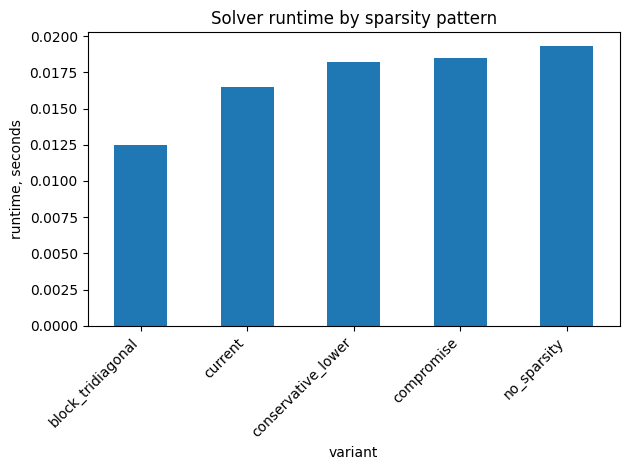

In [18]:
ax = summary["runtime_sec"].sort_values().plot(kind="bar")
ax.set_ylabel("runtime, seconds")
ax.set_title("Solver runtime by sparsity pattern")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

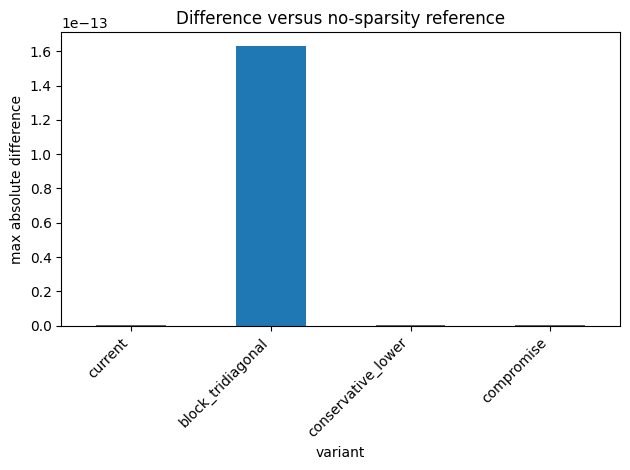

In [19]:
ax = accuracy.drop(index="no_sparsity")["max_abs_state_diff_vs_no_sparsity"].plot(kind="bar")
ax.set_ylabel("max absolute difference")
ax.set_title("Difference versus no-sparsity reference")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Inspect warnings, if any

In [20]:
for name, data in results.items():
    if data["warnings"]:
        print(f"\n{name}")
        for warning in data["warnings"]:
            print(" -", warning.message)

## Suggested interpretation

For this model, I would usually choose the fastest option that:

1. succeeds reliably,
2. gives essentially the same solution as `no_sparsity`, and
3. does not trigger solver or conservation warnings.

On small test cases, several patterns may look identical because BDF may evaluate the Jacobian only once. The differences become more informative when you increase `J`, `N`, the final time, or the stiffness of the parameters.